In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.image as img
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error as mse
from tqdm import tqdm

# import tensorflow as tf
# from tensorflow import keras 
# from tensorflow.keras import layers, Sequential, Model
# from tensorflow.keras import activations
# from tensorflow.keras import backend as bk
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import Lambda, Input, BatchNormalization, ConvLSTM3D, Conv3D, Masking, SpatialDropout3D, Bidirectional
# from tensorflow.keras.activations import relu, sigmoid
# from tensorflow.keras.initializers import RandomNormal
# from tensorflow.keras.optimizers import Adam, SGD
# from tensorflow.python.keras.layers.core import SpatialDropout2D
# from keras import backend as K


In [2]:
def extract_number(filename):
    # Split by '_' and get the last part before '.'
    return int(filename.split('_')[-1].split('.')[0])

def load_sample(data_path):
    # data_path = data_path.numpy().decode()
    # print(data_path)
    sample = np.load(data_path)
    
    ign_pat = sample['ignition_type']
    if ign_pat == 'Ignite_Strip_Northwards.dat':
        ig = np.load('/home/pgmlvol/data/ignition_patterns/ignite_strip_north.npy')
    elif ign_pat == 'Ignite_Aerial.dat':
        ig = np.load('/home/pgmlvol/data/ignition_patterns/ignite_aerial.npy')
    elif ign_pat == 'Ignite_LongFireline_Inwards.dat':
        ig = np.load('/home/pgmlvol/data/ignition_patterns/ignite_long_rel_in.npy')
    elif ign_pat == 'Ignite_LongFireline_Outwards.dat':
        ig = np.load('/home/pgmlvol/data/ignition_patterns/ignite_long_rel_out.npy')
    else:
        return ign_pat,None, None
    
    shp = sample['fuel_density'].shape  # (601, 1, 300, 300)
    ws = np.full(shp, sample['wind_speed'], dtype=np.float32)[:, :, 1:-1, 1:-1]
    wd = np.full(shp, sample['wind_direction'], dtype=np.float32)[:, :, 1:-1, 1:-1]
    sm = sample['source_map'].astype(np.float32)[:, :, 1:-1, 1:-1]
    feature = np.concatenate([ws, wd,ig, sm], axis=1)  # (601, 3, 300, 300)
    # feature = feature[:, :, 1:-1, 1:-1]  # Cropping
    feature = np.moveaxis(feature, 1, -1)  # Change shape to (601, 296, 296, 3)
    target = sample['fuel_density'].astype(np.float32)  # (601, 1, 300, 300)
    target = target[:, :, 1:-1, 1:-1]  # Cropping
    target = np.moveaxis(target, 1, -1)  # Change shape to (601, 296, 296, 1)
    print(feature.shape)
    print(target.shape)
    
    return ign_pat,feature, target

def load_dataset(data_dir):
    datasets, ys, test_datasets, test_ys = [], [], [], []
    path_list = os.listdir(data_dir)
    path_list = sorted(os.listdir(data_dir), key=extract_number)

    print(path_list)
    for i in range(60):
        n = (i + 3) / 5
        if n.is_integer() and n > 0:
            continue
        print("Creating Dataset")
        print(path_list[i])
        ig, feat , tar =  load_sample(os.path.join(data_dir, path_list[i]))
        if ig == 'Ignite_Strip_Southwards.dat':
            continue
        # datasets.append(feat)
        # ys.append(tar)
        ig1, feat1 , tar1 =  load_sample(os.path.join(data_dir, path_list[i+60]))
        if ig1 == 'Ignite_Strip_Southwards.dat':
            continue
        # test_datasets.append(feat1)
        # test_ys.append(tar1)
    
    # print(np.array(datasets).shape)
    # print(np.array(test_datasets).shape)
    # print(np.array(test_ys).shape)
    # print(np.array(ys).shape)
    
        with open(f'/home/pgmlvol/data/dataset_3/train_features_{i}.npy','wb') as f: 
            np.save(f,np.array(feat)) #(601, 298, 298, 4)
        
        with open(f'/home/pgmlvol/data/dataset_3/test_features_{i+60}.npy','wb') as f: 
            np.save(f,np.array(feat1)) 
            
            
        with open(f'/home/pgmlvol/data/dataset_3/test_ys_{i+60}.npy','wb') as f: 
            np.save(f,np.array(tar1))
        
        with open(f'/home/pgmlvol/data/dataset_3/train_ys_{i}.npy','wb') as f: 
            np.save(f,np.array(tar)) #(601, 298, 298, 1)

load_dataset('/home/pgmlvol/')     

FileNotFoundError: [Errno 2] No such file or directory: '/home/pgmlvol/data/train'

In [2]:
filepaths = glob.glob("/home/pgmlvol/data/data_lite" + '/*')
# print(sorted([x.split("/")[-1].split("-")[-1].replace(".npy","") for x in filepaths if 'train-features' in x]))
sorted([x for x in filepaths if 'train-features' in x])
# print(sorted([x.split("/")[-1].split("-")[-1].replace(".npy","") for x in filepaths if 'train-y' in x]))
print(sorted([x for x in filepaths if 'train-y' in x]))
nums = sorted([x.split("/")[-1].split("-")[-1].replace(".npy","") for x in filepaths if 'train-features' in x])
print(nums)

['/home/pgmlvol/data/data_lite/train-y-1011.npy', '/home/pgmlvol/data/data_lite/train-y-1037.npy', '/home/pgmlvol/data/data_lite/train-y-1059.npy', '/home/pgmlvol/data/data_lite/train-y-1066.npy', '/home/pgmlvol/data/data_lite/train-y-1090.npy', '/home/pgmlvol/data/data_lite/train-y-1097.npy', '/home/pgmlvol/data/data_lite/train-y-136.npy', '/home/pgmlvol/data/data_lite/train-y-138.npy', '/home/pgmlvol/data/data_lite/train-y-14.npy', '/home/pgmlvol/data/data_lite/train-y-199.npy', '/home/pgmlvol/data/data_lite/train-y-21.npy', '/home/pgmlvol/data/data_lite/train-y-217.npy', '/home/pgmlvol/data/data_lite/train-y-283.npy', '/home/pgmlvol/data/data_lite/train-y-295.npy', '/home/pgmlvol/data/data_lite/train-y-30.npy', '/home/pgmlvol/data/data_lite/train-y-301.npy', '/home/pgmlvol/data/data_lite/train-y-304.npy', '/home/pgmlvol/data/data_lite/train-y-323.npy', '/home/pgmlvol/data/data_lite/train-y-326.npy', '/home/pgmlvol/data/data_lite/train-y-330.npy', '/home/pgmlvol/data/data_lite/train-

In [3]:
for i in range(60):
        n = (i + 3) / 5
        if n.is_integer() and n > 0:
            print(i)
            continue

2
7
12
17
22
27
32
37
42
47
52
57


In [14]:
def load_dataset():
    datasets, ys = [], []
    test_datasets, test_ys = [], []

    filepaths = glob.glob("/home/pgmlvol/data/data_lite" + '/*')
    print(filepaths)
    # filepaths = filepaths[:25]
    
    paths = sorted([x for x in filepaths if 'train-features' in x])
    for filepath in paths:
        features = np.load(filepath)
        datasets.append(features)
    
    paths = sorted([x for x in filepaths if 'train-y' in x])
    for filepath in paths:
        features = np.load(filepath)
        ys.append(features)
        
    paths = sorted([x for x in filepaths if 'test-features' in x])
    for filepath in paths:
        features = np.load(filepath)
        test_datasets.append(features)
        
    paths = sorted([x for x in filepaths if 'test-y' in x])
    for filepath in paths:
        features = np.load(filepath)
        test_ys.append(features)
    
    # for filepath in tqdm(filepaths, desc="Loop over dataset"):
    #     if filepath.endswith('.npy'):
    #         filename = os.path.basename(filepath)
    #         if filename.startswith('train-features'):
    #             features = np.load(filepath)
    #             datasets.append(features)
    #         elif filename.startswith('test-features'):
    #             features = np.load(filepath)
    #             test_datasets.append(features)  
    #         elif filename.startswith('train-y'):
    #             labels = np.load(filepath)
    #             ys.append(labels)
    #         elif filename.startswith('test-y'):
    #             labels = np.load(filepath)
    #             test_ys.append(labels)
    
    return np.array(datasets), np.array(ys), np.array(test_datasets), np.array(test_ys)


In [6]:
def load_dataset():
    datasets, ys = [], []
    test_datasets, test_ys = [], []

    features = np.load('train_features.npy')
    features = features[:,:,0,:,:,:]
    datasets.append(features)
    
    features = np.load('test_features.npy')
    features = features[:,:,0,:,:,:]
    test_datasets.append(features)
    
    features = np.load('train_ys.npy')
    features = features[:,:,0,:,:,:]
    ys.append(features)
    
    features = np.load('test_ys.npy')
    features = features[:,:,0,:,:,:]
    test_ys.append(features)
    
    return datasets, ys, test_datasets, test_ys


In [15]:
datasets, ys, test_datasets, test_ys = load_dataset()

['/home/pgmlvol/data/data_lite/train-features-570.npy', '/home/pgmlvol/data/data_lite/train-features-199.npy', '/home/pgmlvol/data/data_lite/test-y-790.npy', '/home/pgmlvol/data/data_lite/train-y-14.npy', '/home/pgmlvol/data/data_lite/test-features-143.npy', '/home/pgmlvol/data/data_lite/test-features-187.npy', '/home/pgmlvol/data/data_lite/test-features-955.npy', '/home/pgmlvol/data/data_lite/train-y-30.npy', '/home/pgmlvol/data/data_lite/train-features-499.npy', '/home/pgmlvol/data/data_lite/test-y-1026.npy', '/home/pgmlvol/data/data_lite/test-y-102.npy', '/home/pgmlvol/data/data_lite/test-y-482.npy', '/home/pgmlvol/data/data_lite/train-y-635.npy', '/home/pgmlvol/data/data_lite/test-features-473.npy', '/home/pgmlvol/data/data_lite/train-features-1097.npy', '/home/pgmlvol/data/data_lite/train-y-520.npy', '/home/pgmlvol/data/data_lite/test-y-926.npy', '/home/pgmlvol/data/data_lite/train-y-474.npy', '/home/pgmlvol/data/data_lite/test-y-1077.npy', '/home/pgmlvol/data/data_lite/train-y-51

In [16]:
datasets[0].shape

(50, 1, 298, 298, 4)

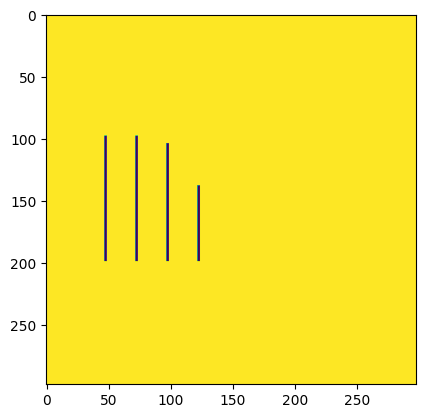

In [20]:
import matplotlib.pyplot as plt
plt.imshow(datasets[1][49,0,:,:,3])

In [27]:
np.array(datasets)[:,49,0,:,:,3].shape

(50, 298, 298)

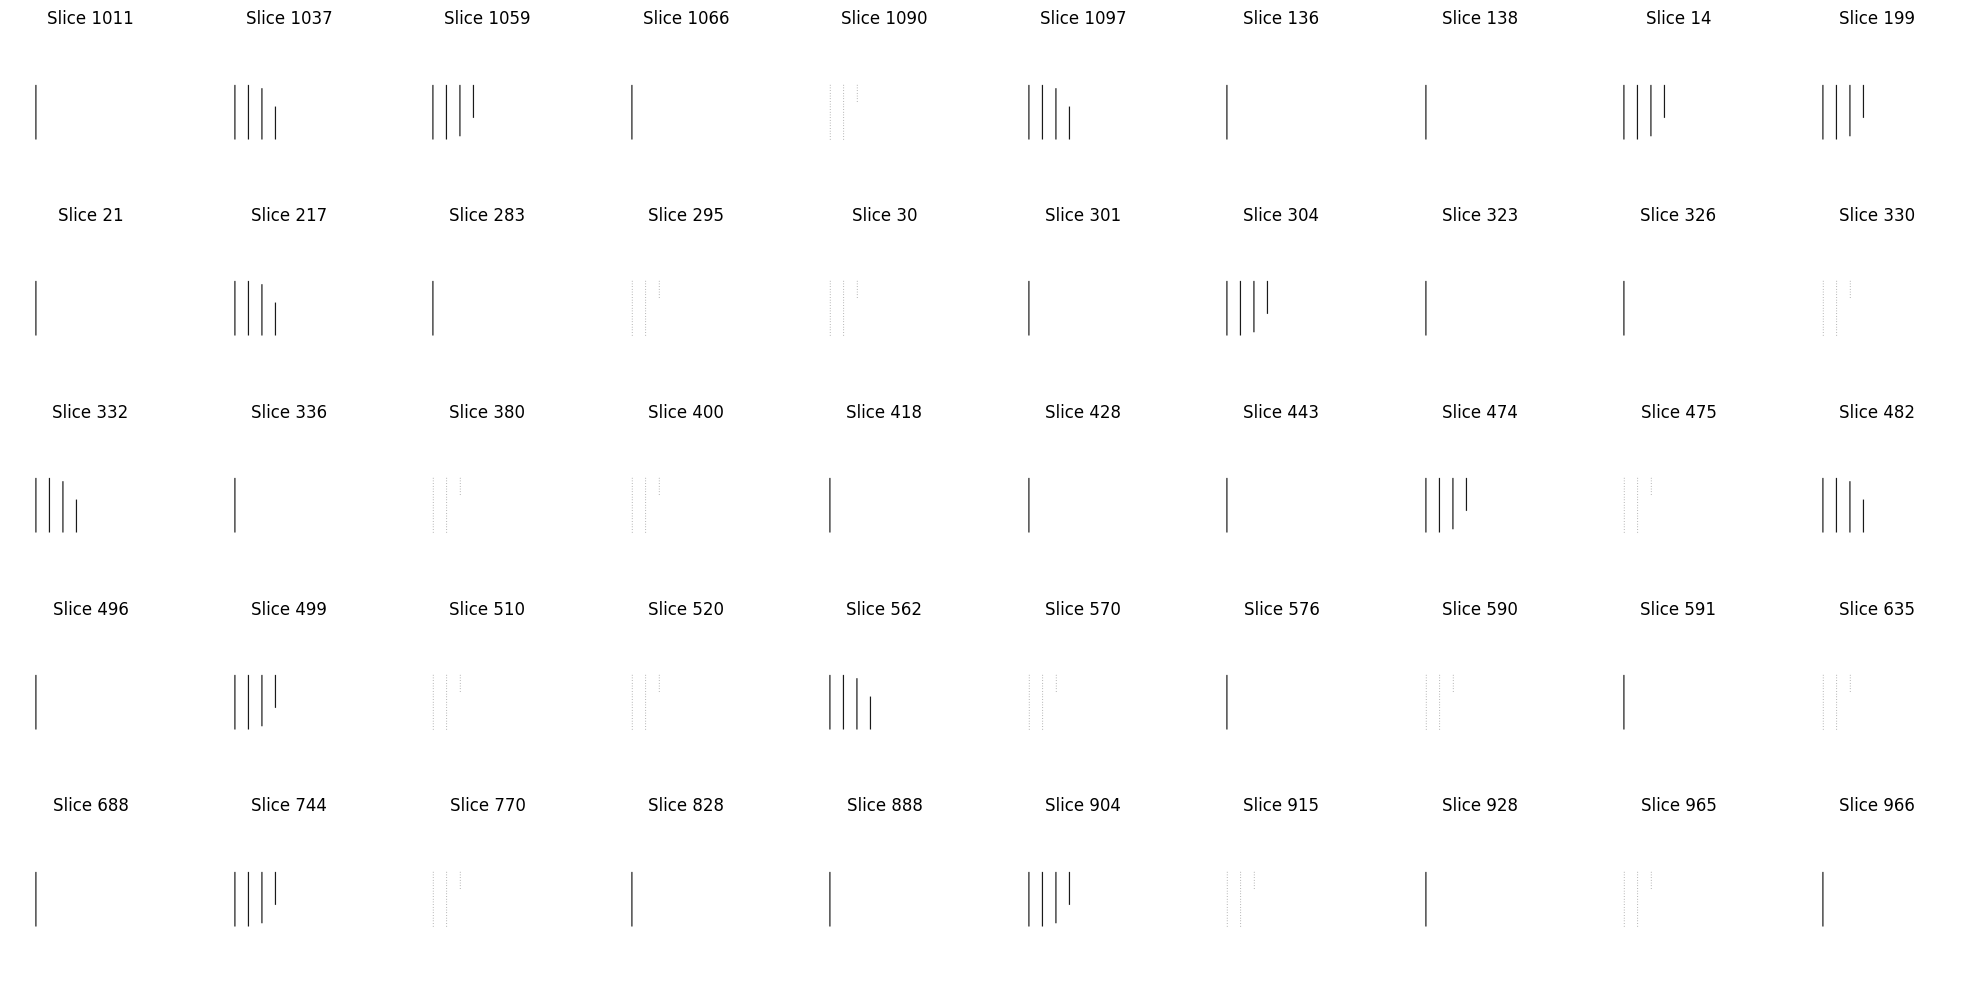

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming `data` is your 3D array of shape (50, 298, 298)
data = np.array(datasets)[:,49,0,:,:,3]  # Example array with random data

# Function to plot slices
def plot_all_slices(data):
    num_slices = data.shape[0]
    fig, axes = plt.subplots(5, 10, figsize=(20, 10))

    for i, ax in enumerate(axes.flat):
        ax.imshow(data[i], cmap='gray')
        ax.set_title(f'Slice {nums[i]}')
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Plot all slices
plot_all_slices(data)


(601, 1, 298, 298)


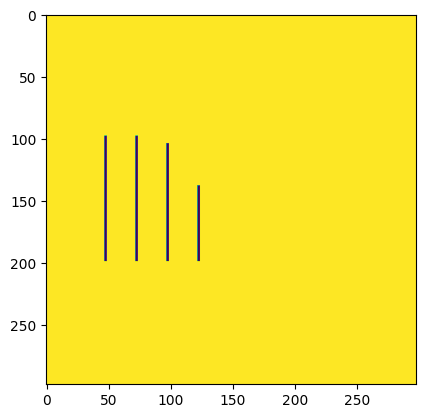

In [54]:
arr = datasets[1][:,0,:,:,3]

# Repeat the last slice (49th index) to extend from 50th to 600th
last_slice = arr[-1, :, :]  # This is the last slice with index 49

# Create a new array by repeating the last slice (600-50 = 550 times)
repeated_slices = np.tile(last_slice, (551, 1, 1))

# Concatenate the original array with the repeated slices
extended_arr = np.concatenate((arr, repeated_slices), axis=0)
reshaped_arr = np.expand_dims(extended_arr, axis=1)

with open("/home/pgmlvol/data/ignition_patterns/ignite_long_rel_out.npy", "wb") as f:
    np.save(f, reshaped_arr)
print(reshaped_arr.shape)
plt.imshow(reshaped_arr[600,0,:,:])


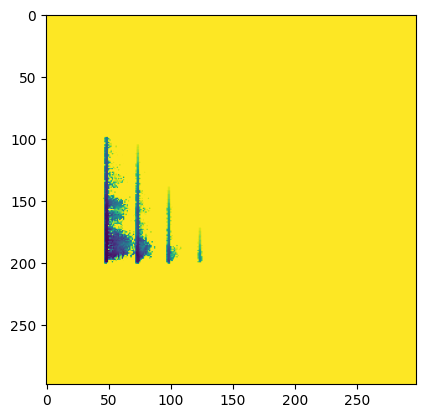

In [33]:
plt.imshow(ys[7][39][0])

In [40]:
# X = datasets[0][49][0][:,:,3] == datasets[3][49][0][:,:,3]
# np.sum(X),X.ravel().shape[0] 
# wind_speeds = []
# for t in range(50):
#     np.concatenate([wind_speeds, np.unique(datasets[0][t][0][:,:,2])])
# wind_speeds

[]

In [42]:
import pandas as pd
import numpy as np

# Read the CSV file
df = pd.read_csv('/home/pgmlvol/data/uniform-pgml-success_list_simulation_runs.csv')

# Specify the column for which you want unique values and their indices
column_name = 'ignition_type_metadata'

# Get the unique values from the specified column
unique_values = df[column_name].unique()

# Find the indices where each unique value occurs
unique_indices = {val: np.where(df[column_name] == val)[0].tolist() for val in unique_values}

# Output the unique values and their respective indices
for value, indices in unique_indices.items():
    print(f"Value: {value}, Indices: {indices}")


Value: Ignite_Aerial.dat, Indices: [0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, 85, 90, 95, 100, 105, 110, 115, 120, 125, 130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190, 195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255, 260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315, 320, 325, 330, 335, 340, 345, 350, 355, 360, 365, 370, 375, 380, 385, 390, 395, 400, 405, 410, 415, 420, 425, 430, 435, 440, 445, 450, 455, 460, 465, 470, 475, 480, 485, 490, 495, 500, 505, 510, 515, 520, 525, 530, 535, 540, 545, 550, 555, 560, 565, 570, 575, 580, 585, 590, 595, 600, 605, 610, 615, 620, 625, 630, 635, 640, 645, 650, 655, 660, 665, 670, 675, 680, 685, 690, 695, 700, 705, 710, 715, 720, 725, 730, 735, 740, 745, 750, 755, 760, 765, 770, 775, 780, 785, 790, 795, 800, 805, 810, 815, 820, 825, 830, 835, 840, 845, 850, 855, 860, 865, 870, 875, 880, 885, 890, 895, 900, 905, 910, 915, 920, 925, 930, 935, 940, 945, 950, 955, 960, 965, 970, 975, 980, 9

In [28]:
X = datasets[0][0][:,:,:,0] == ys[0][0][:,:,:]
np.sum(X) == X.ravel().shape[0] 
datasets[7][39][:,0,,2]

array([0.], dtype=float32)

In [5]:
with open("train_features.npy", "wb") as f:
    np.save(f, datasets)
with open("train_ys.npy", "wb") as f:
    np.save(f, ys)
with open("test_features.npy", "wb") as f:
    np.save(f, test_datasets)
with open("test_ys.npy", "wb") as f:
    np.save(f, test_ys)

In [9]:
def extract_number(filename):
    # Split by '_' and get the last part before '.'
    return int(filename.split('_')[-1].split('.')[0])
path_list = os.listdir('/home/pgmlvol/data/train')
print(path_list)
path_list = sorted(os.listdir('/home/pgmlvol/data/train'), key=extract_number)
print(path_list)

['features_63.npz', 'features_100.npz', 'features_222.npz', 'features_235.npz', 'features_231.npz', 'features_337.npz', 'features_276.npz', 'features_47.npz', 'features_246.npz', 'features_506.npz', 'features_293.npz', 'features_173.npz', 'features_55.npz', 'features_307.npz', 'features_308.npz', 'features_83.npz', 'features_61.npz', 'features_460.npz', 'features_264.npz', 'features_198.npz', 'features_345.npz', 'features_30.npz', 'features_453.npz', 'features_283.npz', 'features_183.npz', 'features_209.npz', 'features_409.npz', 'features_46.npz', 'features_390.npz', 'features_218.npz', 'features_482.npz', 'features_394.npz', 'features_411.npz', 'features_180.npz', 'features_395.npz', 'features_349.npz', 'features_271.npz', 'features_115.npz', 'features_174.npz', 'features_495.npz', 'features_35.npz', 'features_15.npz', 'features_347.npz', 'features_365.npz', 'features_85.npz', 'features_289.npz', 'features_79.npz', 'features_340.npz', 'features_74.npz', 'features_52.npz', 'features_99

In [5]:
test_ys.shape

(49, 50, 1, 298, 298, 1)

In [64]:
x = np.load('/home/pgmlvol/data/train/features_10.npz')
print(list(x.keys()))
arr = x['ignition_type']
if arr == 'Ignite_Strip_Northwards.dat':
    print("true")
else:
    print("false")

['wind_speed', 'wind_direction', 'surface_moisture', 'ignition_type', 'source_map', 'fuel_density']
true


In [1]:
import os
import random
import shutil

# Define the directory containing the .npz files
dataset_dir = '/home/pgmlvol/jjaiswal/dataset/'

# List all .npz files in the directory
file_paths = [os.path.join(dataset_dir, fname) for fname in os.listdir(dataset_dir) if fname.endswith('.npz')]

# Shuffle the file paths
random.shuffle(file_paths)

# Calculate the split index
split_index = int(0.8 * len(file_paths))

# Split the file paths into training and test sets
train_files = file_paths[:split_index]
test_files = file_paths[split_index:]

# Define the directories to save the training and test datasets
train_dir = os.path.join(dataset_dir, 'train')
test_dir = os.path.join(dataset_dir, 'test')

# Create the directories if they don't exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Move the training files to the train directory
for file_path in train_files:
    shutil.move(file_path, os.path.join(train_dir, os.path.basename(file_path)))

# Move the test files to the test directory
for file_path in test_files:
    shutil.move(file_path, os.path.join(test_dir, os.path.basename(file_path)))
